<a href="https://colab.research.google.com/github/emisseldine/OpenLinear/blob/main/Chapter4/workbooks/kmeans.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<center>
<p style="text-align:center">
    <a href="https://raw.githubusercontent.com/emisseldine/OpenLinear/main/BackMatter/logo.png" target="_blank">
    <img src="https://raw.githubusercontent.com/emisseldine/OpenLinear/main/BackMatter/logo.png" width="200" alt="Missel Books Logo">
    </a>
</p>


# 1.6 The $k$-means Algorithm
</center>

---

We begin by importing the $k$-means algorithm as implemented in the textbook.

First, we load `clustering_objective` which calculates $\mathcal{J}^\text{clust}$.

In [1]:
import numpy as np

def clustering_objective(data, clustering, reps):
    J_obj = 0                                                           #Initialize clustering objective
    for i in range(len(data)):                                          #for-loop going through all data vectors "data[i]"
        J_obj += np.linalg.norm(data[i] - reps[int(clustering[i])])**2  #Running total calculating the numerator of the clustering objective
    return J_obj/len(data)                                              #the running total divided by the number of data gives the clustering objective

Second, we load `update_cluster` which updates the cluster assignment vector $\boldsymbol{c}$ using the current representatives $\boldsymbol{z}_1, \ldots, \boldsymbol{z}_k$.


In [2]:
#inputs a set of data vectors "data" and a set of cluster representatives "reps"
#outputs a cluster assignment vector by identifying which representative is nearest to each data vector
def update_cluster(data,reps):
    new_clustering = np.zeros(len(data))                        #Initialize cluster assignment vector
    for i in range(len(data)):                                  #for-loop running over the N data vectors: "data[i]"
        distance = np.zeros(len(reps))                          #Initialize the vector of distances between the fixed vector "data[i]" with the cluster representatives
        for j in range(len(reps)):                              #for-loop running over the k cluster representatives: "reps[j]"
            distance[j] = np.linalg.norm(data[i] - reps[j])     #computes the distance between data vector "data[i]" and cluster representative "reps[j]"
        new_clustering[i] = np.argmin(distance)                 #grabs the nearest neighbor
    return new_clustering


Third, we load `update_reps` which updates the cluster representatives $\boldsymbol{z}_1, \ldots, \boldsymbol{z}_k$ using the current cluster assignment vector $\boldsymbol{c}$.



In [3]:
#inputs a set of data vectors "data" and a cluster assignment vector "clustering"
#outputs a new set of cluster representatives by replacing the current representatives with the mean of each of the clusters of vectors
def update_reps(data, clustering):
    new_reps = [];                            #Initialize the set of new representatives
    for j in range(int(max(clustering)+1)):   #for-loop running over the k cluster representatives
        sum = np.zeros(len(data[0]))          #Initialize a running sum of the vectors "data[i]" in cluster j
        count = 0                             #Initialize the size of cluster j
        for i in range(len(data)):            #for-loop running over the N data vectors: "data[i]"
            if clustering[i] == j:            #check to see if vector "data[i]" belongs to cluster j by referencing the assignment "clustering[i]"
                sum = sum+data[i]             #adds data from "data[i]" to running sum
                count += 1                    #increases count of cluster j by 1
        if count > 0:
            new_reps.append(sum/count)        #appends mean vector j to list of new representatives
    return np.array(new_reps)


Before loading the four procedure which implements the algorithm and runs until $\mathcal{J}^\text{clust}$ no longer improves sufficiently, we will try our hands on running the $k$-means algorithm "manually."

###For Exercises 1-2 below, perform $j$ iterations of the $k$-means algorithm on the data set $X$, given below, for the given number of clusters $k$ and initial representations $Z = \{\boldsymbol{z}_1,\ldots, \boldsymbol{z}_k\}$. Report the final representatives $Z$ and cluster assignment vector $\boldsymbol{c}$.


---


*An example is provided in Exercise 0.*

0. Compute $j=1$ iterations with $k=3$ clusters and initial representativs $Z = \{\boldsymbol{e}_1,\boldsymbol{e}_2,\boldsymbol{e}_3\}$.

In [6]:
import numpy as np

X = np.array([[1,-1,0],  #vectors to cluster
              [1,2,3],
              [-1,0,1],
              [-2,4,3],
              [5,1,0],
              [-1,1,0],
              [1,0,3],
              [5,-5,0],
              [3,-1,2],
              [3,4,-5]])
k = 3                     #number of clusters
Z = np.array([[1,0,0],    #initial reps
              [0,1,0],
              [0,0,1]])

# j = 1
c = update_cluster(X,Z)
Z = update_reps(X,c)

print(Z, c)

[[ 3.5        -1.5         0.5       ]
 [ 0.          3.         -0.66666667]
 [ 0.33333333  0.66666667  2.33333333]] [0. 2. 2. 1. 0. 1. 2. 0. 0. 1.]


1. Compute $j=2$ iterations with $k=3$ clusters and initial representativs $Z = \{\boldsymbol{e}_1,\boldsymbol{e}_2,\boldsymbol{e}_3\}$.


In [ ]:
### EXERCISE 1#######################################


<details><summary>Click here for the solution</summary>

```Python
Z = [[ 3.5    -1.5   0.5 ]
     [ 1.     2.5    -2.5]
     [ -0.25  1.5    2.5 ]]
c = [0. 2. 2. 2. 0. 1. 2. 0. 0. 1.]
 ```

</details>

2. Compute $j=3$ iterations with $k=3$ clusters and initial representativs $Z = \{\boldsymbol{e}_1,\boldsymbol{e}_2,\boldsymbol{e}_3\}$.


In [ ]:
### EXERCISE 2#######################################


<details><summary>Click here for the solution</summary>

```Python
Z = [[ 3.5    -1.5   0.5 ]
     [ 3.     4      -5  ]
     [ -0.4   3.5    2   ]]
c = [0. 2. 2. 2. 0. 2. 2. 0. 0. 1.]
 ```

</details>

Let us now load the last procedure Kmeans_alg which which runs the $k$-means algorithm.


In [7]:
#inputs a set of data vectors "data" and a set of cluster representatives "reps"
#"show_steps" is an optional parameter, which by default is False, which if toggled to True would show the steps of the algorithm
#outputs four quantities as explained below:
#1st, the final set of representatives: "new_reps"
#2nd, the final partition: "clustering"
#3rd, the sequence of clustering objective for each iteration with the 0th index the initial objective: "J_obj"
#4th, the number of iterations to complete the algorithm
def Kmeans_alg(data, reps, show_steps=False):
    J_obj = []                                                  #Initialize the cluster objective sequence
    clustering = update_cluster(data, reps)                     #calculates the initial clustering assignment (to avoid an error when we lose a group
    J_obj.append(clustering_objective(data, clustering, reps))  #calculates the initial clustering objective

    if show_steps:
        print("Iteration", len(J_obj)-1, ":\n (Update Cluster)")
        print("c = ", clustering)
        print(" Z = ", reps)
        print("J^clust = ", J_obj[-1], "\n")

    Stop = False                                                #Initialize the boolean for terminating the while loop
    while not(Stop):
        new_reps = update_reps(data, clustering)
        if show_steps:
            print("Iteration", len(J_obj), ":\n (Update Reps)")
            print(" Z = ", new_reps)

        clustering = update_cluster(data, new_reps)
        J_obj.append(clustering_objective(data, clustering, new_reps))
        if show_steps:
            print("(Update Cluster)")
            print("c = ", clustering)
            print("J^clust = ", J_obj[-1], "\n")
        Stop = (len(new_reps) == len(reps)) and (np.linalg.norm(np.array(new_reps) - np.array(reps)) < 1e-6)
                                                                #checks to see if any clusters were lost #checks if change in reps is significant
        reps = new_reps                                         #update reps for next iteration

    return new_reps, clustering, J_obj, len(J_obj)-1

---

### Consider the same data set from Example 1.6.2 in the textbook. Find a clustering for which $\mathcal{J}^\text{clust} < 5.208$ using $k=4$. Report your initial representatives (which you will pick), your final representatives, your final clustering assignment, and the final clustering objective.

In [11]:
### EXERCISE 3#######################################
X = np.array([ [1,2,3], [4,5,6], [1,2,0], [0,0,3], [3,2,1], [2,2,0], [0,5,0], [2,3,1], [6,6,4], [9,3,2], [2,3,4], [7,5,0], [ 2,7,8] ])

#Pick a good choice on Z
# Kmeans_alg(X,Z)

---

### For Exercises 5-7, consider the following data set of 100 vectors. Compute three different clusterings for the given $k$ using three different initializations. To report your clustering include a colored graphic illustrating the clustering, list the cluster representatives, and $\mathcal{J}^\text{clust}$ for each of these three clusterings.



In [31]:
def Kmeans_scatter(data,reps,labels):
  k=len(reps)
  grps = [[X[i,:] for i in range(len(X)) if labels[i]==j] for j in range(k)]
  for i in range(k):
    plt.scatter([c[0] for c in grps[i]],[c[1] for c in grps[i]])
  plt.scatter([z[0] for z in reps],[z[1] for z in reps],c='black',marker='x',s=50)
  plt.show()

---


*An example is provided in Exercise 4.*

4. Compute three clusterings for $k=2$.

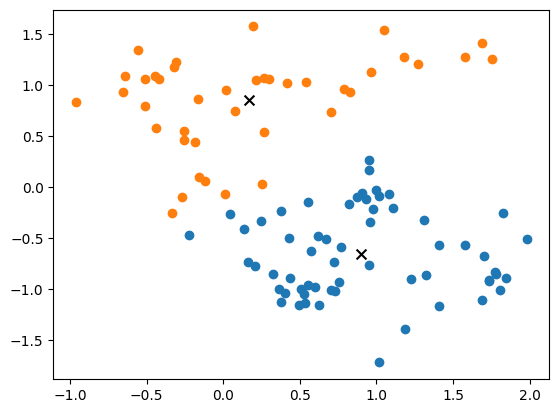

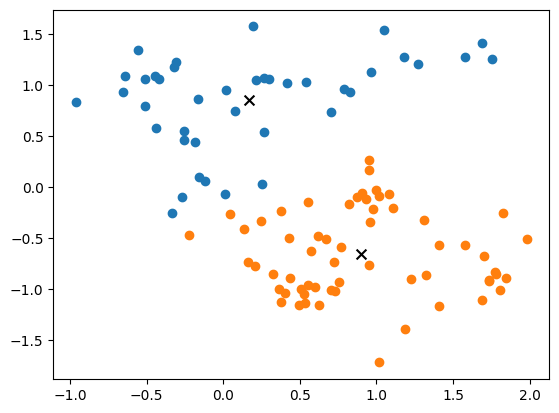

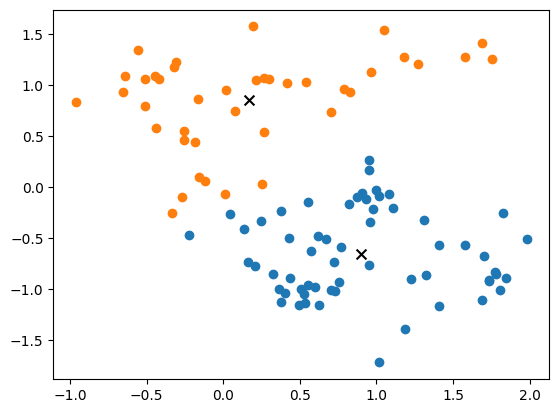

In [32]:
# Consider the following data set of n = 100 vectors.
X = np.array([[ 0.011499775310454985, -0.06353071139753803],
[ -0.26806860191340304, -0.0911109519553983],
[ -0.33192608299119314, -0.25633299184031716],
[ -0.1807122247382386, 0.4407823656766903],
[ 0.04755725914233897, -0.26038121782191964],
[ -0.2218959599585165, -0.46445115145460325],
[ -0.15720062347314487, 0.09831127821772508],
[ -0.11737628492132425, 0.06322469336557392],
[ -0.254182338438016, 0.46248410082371066],
[ -0.43909490168823184, 0.5809660426246169],
[ 0.21176006985732831, 1.048406087811497],
[ 0.19173151514779985, 1.5772962591069986],
[ 0.2971332017652109, 1.064039078904691],
[ 0.07917226251135184, 0.7490554663368822],
[ 0.2639118824928691, 1.0752542053739997],
[ 0.5372977696283332, 1.036769283189558],
[ 0.4181336907917003, 1.0237111890602981],
[ -0.16251880690627085, 0.8678728394531069],
[ -0.3189020635774326, 1.1795889910940704],
[ -0.5075626762419931, 0.7988086283167466],
[ 0.8269182622564538, 0.9376481206189049],
[ 0.7062514580575565, 0.737016926160736],
[ 0.9660731848931493, 1.126927004885705],
[ 1.1773296447091877, 1.2757715193118528],
[ 1.756214210380178, 1.256692979216825],
[ 1.2699540575385448, 1.2117029396254702],
[ 0.7885165513053876, 0.9598620938111682],
[ 1.6890809127526807, 1.4200118857511428],
[ 1.5752834475149737, 1.2789676692023715],
[ 1.0523805196933704, 1.5434544502126877],
[ 1.2259106600330734, -0.8978919255273496],
[ 0.7253402516314809, -0.7283452009098872],
[ 0.32263393466087575, -0.8460795086539056],
[ 1.0201501479429478, -1.7182430376269078],
[ 0.5323002483607984, -1.1321713406135534],
[ 1.3254747787720103, -0.8587676896616584],
[ 1.4078032219972128, -0.5616177786632082],
[ 1.7316474350015025, -0.9176614871654156],
[ 1.184685490546223, -1.3851624548168016],
[ 0.9513289656008778, -0.7611989358689963],
[ 0.018610029113234172, 0.9538085232074225],
[ -0.446631451896232, 1.0954399045781975],
[ -0.2527719861344526, 0.5477101309865007],
[ -0.30934040367505067, 1.23047363046694],
[ -0.9611101507006983, 0.8322061573342004],
[ -0.5546657032971068, 1.3501952708531475],
[ -0.6524149234749772, 0.9369781770811536],
[ -0.6409264016654703, 1.0903088056413974],
[ -0.5123635803793734, 1.0638675129226425],
[ -0.4190676184921376, 1.0588171245871274],
[ 0.703284915870159, -1.0068331196347922],
[ 0.40447124150341984, -1.037670286112816],
[ 0.5296648386558154, -1.0492904103781007],
[ 0.551113009969552, -0.9598377076582264],
[ 0.4967557047378246, -1.1589919233307204],
[ 0.36520358569991734, -1.0022616314100707],
[ 0.3778351990362021, -1.1293152998298237],
[ 0.6021294680591185, -0.975894520948475],
[ 0.6280584918977341, -1.1558240317054445],
[ 0.509641922560463, -0.9929632629694748],
[ 0.1630855255770059, -0.7335233863877533],
[ 0.6169167547080051, -0.473549644614539],
[ 0.7330276629198617, -1.0145822739738608],
[ 0.6722185626314987, -0.5065969505854474],
[ 0.571994529046489, -0.6257916296234889],
[ 0.21080756579677795, -0.7711100514491268],
[ 0.2474329288688758, -0.3303369462067695],
[ 0.38048626001895547, -0.23143849230707148],
[ 0.7578823745272825, -0.9324635843838731],
[ 0.42666058023235054, -0.49396340598220817],
[ 0.9585756837331035, -0.3409137133391019],
[ 1.0155270840916915, -0.08959069274407203],
[ 0.9342222413847283, -0.11858339351461941],
[ 0.8223020301806827, -0.16670599706753103],
[ 0.9509725646078434, 0.27124055703943317],
[ 1.3082380420505269, -0.31891623348821707],
[ 0.555120274183072, -0.14368370321260343],
[ 0.7678617910000151, -0.5870573626649148],
[ 1.1089885851947607, -0.20284644740530453],
[ 0.9779116200022511, -0.2143500423668491],
[ 1.8232965408889554, -0.2547468789278462],
[ 1.7331387086985606, -0.9104359881393999],
[ 1.7816026449351243, -0.8481857265272674],
[ 1.8445924743295163, -0.8863371822827776],
[ 1.6887871627480715, -1.1066462275084639],
[ 1.8097727990186252, -1.010976866612518],
[ 1.5809744384796107, -0.567877345593579],
[ 1.702596860805505, -0.6775092192418015],
[ 1.7715589402384084, -0.8285201819477293],
[ 1.981445811412673, -0.5080652659333683],
[ 0.2527588733027669, 0.03153075046393112],
[ 0.8718660495889615, -0.09339204334051672],
[ 0.13808126159426448, -0.4050854226605656],
[ 1.082730783251869, -0.06186079623704191],
[ 1.4061282817773362, -1.1623031997546525],
[ 0.26715842314763183, 0.543541991706253],
[ 0.9971507373413223, -0.02725845958354786],
[ 0.9543829638283083, 0.16866762403852925],
[ 0.9045006628426874, -0.05835140413310361],
[ 0.4372646513678142, -0.8876586880633819]])

import matplotlib.pyplot as plt

k=2
## First Attempt #####
Z = X[:k]
Z, c, Jclust, steps = Kmeans_alg(X,Z)
Kmeans_scatter(X,Z,c)

## Second Attempt #####
Z = X[-k:]
Z, c, Jclust, steps = Kmeans_alg(X,Z)
Kmeans_scatter(X,Z,c)

## Third Attempt #####
Z = np.identity(2)
Z, c, Jclust, steps = Kmeans_alg(X,Z)
Kmeans_scatter(X,Z,c)


5. Compute three clusterings for $k=3$.

In [ ]:
### EXERCISE 5#######################################
k=3
## First Attempt #####
# Pick initial representatives
Z, c, Jclust, steps = Kmeans_alg(X,Z)
Kmeans_scatter(X,Z,c)

## Second Attempt #####
# Pick initial representatives
Z, c, Jclust, steps = Kmeans_alg(X,Z)
Kmeans_scatter(X,Z,c)

## Third Attempt #####
# Pick initial representatives
Z, c, Jclust, steps = Kmeans_alg(X,Z)
Kmeans_scatter(X,Z,c)

6. Compute three clusterings for $k=4$.

In [ ]:
### EXERCISE 6#######################################
k=4
## First Attempt #####
# Pick initial representatives
Z, c, Jclust, steps = Kmeans_alg(X,Z)
Kmeans_scatter(X,Z,c)

## Second Attempt #####
# Pick initial representatives
Z, c, Jclust, steps = Kmeans_alg(X,Z)
Kmeans_scatter(X,Z,c)

## Third Attempt #####
# Pick initial representatives
Z, c, Jclust, steps = Kmeans_alg(X,Z)
Kmeans_scatter(X,Z,c)

7. Compute three clusterings for $k=10$.

In [ ]:
### EXERCISE 7#######################################
k=10
## First Attempt #####
# Pick initial representatives
Z, c, Jclust, steps = Kmeans_alg(X,Z)
Kmeans_scatter(X,Z,c)

## Second Attempt #####
# Pick initial representatives

Z, c, Jclust, steps = Kmeans_alg(X,Z)
Kmeans_scatter(X,Z,c)

## Third Attempt #####
# Pick initial representatives

Z, c, Jclust, steps = Kmeans_alg(X,Z)
Kmeans_scatter(X,Z,c)

8. Explain which clustering was the best of the nine above and why.

In [ ]:
print('Answer here')

*When completed, download the notebook as a .pdf file and upload it to the course's learning management system, e.g. Canvas. To do this, via Google Chrome, choose `File`, then `Print` (or simply `Ctrl+P`). Then choose printer `Destination` as `Print as PDF.` You may have to adjust setting to print well. For example, set `Layout` as `Landscape` and under `More Settings` turn off `Headers and Footers`.*



---
<center>

##### This Python workbook was produced for [Linear Algebra Done Openly](https://github.com/emisseldine/OpenLinear) by Dr. Andrew Misseldine (2026).
<p style="text-align:center">
    <a href="https://raw.githubusercontent.com/emisseldine/OpenLinear/main/BackMatter/logo.png" target="_blank">
    <img src="https://raw.githubusercontent.com/emisseldine/OpenLinear/main/BackMatter/logo.png" width="200" alt="Missel Books Logo">
    </a>
</p>
</center>